# Complaint severity triage: analysis notebook

**Goal.** Predict the Severity Score (1-6) of a complaint case and, from it, the triage decision:
scores 1-3 are *not progressed*, 4-6 are *progressed for further investigation*.

**Business framing.** The organisation has a *low tolerance for severe cases being classified as low
severity*. A missed severe case (false negative on the progress decision) is much more costly than an
unnecessary investigation (false positive). This asymmetry shapes three choices in this notebook:

1. the metrics we optimise (severe-case recall and an explicit cost, not plain accuracy);
2. the decision rule (a tuned probability threshold instead of the most-likely class);
3. what we report to the business (the trade-off curve, not a single number).

All reusable logic lives in the `severity_triage` package under `src/`; this notebook calls it so that
what is analysed here is exactly what runs in `severity-train` / `severity-predict`.

Sections: 1 Data audit · 2 Cleaning · 3 Features · 4 Modelling · 5 Business risk & threshold ·
6 Explainability · 7 Holdback predictions · 8 Conclusions

In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display

from severity_triage import config as C
from severity_triage.data import load_raw, clean, split_xy
from severity_triage.features import FeatureEngineer
from severity_triage.model import build_baseline_pipeline, build_lgbm_pipeline, decode_scores, severe_probability, SeverityModel
from severity_triage.evaluate import full_evaluation, threshold_curve, choose_threshold, score_metrics, triage_metrics, is_severe
from severity_triage.train import cross_validate_proba
from severity_triage.explain import shap_values, severe_contributions, global_importance, top_drivers

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160, "display.max_columns", 60)
FIG = C.REPORTS_DIR / "figures"; FIG.mkdir(parents=True, exist_ok=True)
SEED = C.RANDOM_SEED
np.random.seed(SEED)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data audit

The data dictionary in the assessment workbook is the contract. Before modelling we check the raw
files against it: schema, types, allowed ranges, missingness, and whether any column is only
available *after* the decision we are trying to predict.

In [2]:
raw_train = load_raw(C.TRAIN_PATH)
raw_hold = load_raw(C.HOLDBACK_PATH)
print("train", raw_train.shape, "| holdback", raw_hold.shape)
print("columns only in train:", sorted(set(raw_train) - set(raw_hold)))
print("duplicate CaseReference (train/holdback):", raw_train.CaseReference.duplicated().sum(), raw_hold.CaseReference.duplicated().sum())
print("date range:", raw_train.CaseCreatedDate.min(), "to", raw_train.CaseCreatedDate.max())

train (2000, 46) | holdback (500, 45)
columns only in train: ['SeverityScore']
duplicate CaseReference (train/holdback): 0 0
date range: 2023-01-01 to 2026-06-30


### 1.1 Target distribution

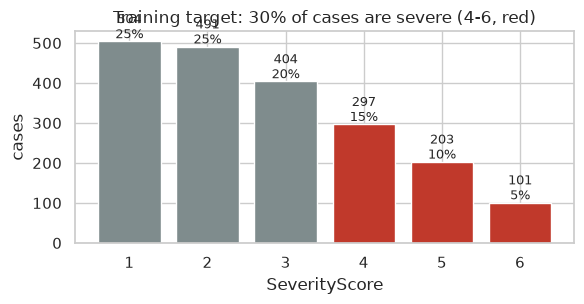

share progressed (>=4): 30.0%


In [3]:
counts = raw_train[C.TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.2))
colors = ["#7f8c8d" if s < 4 else "#c0392b" for s in counts.index]
ax.bar(counts.index, counts.values, color=colors)
for s, n in counts.items():
    ax.text(s, n + 8, f"{n}\n{n/len(raw_train):.0%}", ha="center", fontsize=9)
ax.set(xlabel="SeverityScore", ylabel="cases", title="Training target: 30% of cases are severe (4-6, red)")
plt.tight_layout(); fig.savefig(FIG / "target_distribution.png", dpi=120); plt.show()
print(f"share progressed (>=4): {is_severe(raw_train[C.TARGET]).mean():.1%}")

The classes are imbalanced in the direction that matters: severe cases (4-6) are 30% of the data and
score 6 alone is 5%. A model optimised for accuracy would be biased towards predicting low scores,
which is exactly the failure mode the business cannot tolerate. This is why the model uses balanced
class weights and why the decision threshold is tuned separately (section 5).

### 1.2 Missing values (train vs holdback)

In [4]:
miss = pd.DataFrame({
    "train_missing": raw_train.isna().sum(), "train_%": (100 * raw_train.isna().mean()).round(1),
    "holdback_missing": raw_hold.reindex(columns=raw_train.columns).isna().sum(),
    "holdback_%": (100 * raw_hold.reindex(columns=raw_train.columns).isna().mean()).round(1),
})
display(miss[miss.train_missing + miss.holdback_missing.fillna(0) > 0].sort_values("train_%", ascending=False))

,train_missing,train_%,holdback_missing,holdback_%
FailureTypeSecondary,925,46.2,245,49.0
PrimaryVulnerability,505,25.2,144,28.8
VulnerabilityLevel,404,20.2,118,23.6
PhysicalImpactLevel,336,16.8,82,16.4
Jurisdiction,112,5.6,34,6.8
EvidenceStrength,58,2.9,16,3.2
ExpectedFinancialRedressGBP,56,2.8,12,2.4
RecoveryTimeMonths,54,2.7,14,2.8
OrganisationType,38,1.9,7,1.4
AdditionalCostsGBP,36,1.8,8,1.6


Two different kinds of missingness are present:

* **Structural "None"**: `PhysicalImpactLevel`, `VulnerabilityLevel`, `PrimaryVulnerability` and
  `FailureTypeSecondary` all list `None` as an allowed value in the dictionary, yet `None` never
  appears in the raw data, and the blanks in these columns have the *lowest* mean severity of any
  level (below). The blanks are the `None` category and are filled as such.
* **Random-looking gaps** of 1.5-6% in other columns (`EvidenceStrength`, `Jurisdiction`,
  `EmotionalImpactLevel`, several numerics). These are imputed with the median inside the pipeline,
  with a missing-indicator column so the model can still use the fact that a value was absent.
* `OmbudsmanInvestigationRequired` is 100% missing in the holdback set: see 1.4.

In [5]:
rows = []
for col in C.STRUCTURAL_NONE_COLUMNS:
    g = raw_train.groupby(raw_train[col].fillna("<blank>"))[C.TARGET].agg(["mean", "count"]).round(2)
    g.insert(0, "column", col); rows.append(g)
display(pd.concat(rows).rename_axis("level").reset_index().set_index(["column", "level"]))

mean  count
column               level                               
PhysicalImpactLevel  <blank>                  1.61    336
                     Minor                    2.05    403
                     Moderate                 2.66    508
                     Severe                   4.21    335
                     Significant              3.29    418
VulnerabilityLevel   <blank>                  2.08    404
                     High                     3.46    363
                     Low                      2.53    652
                     Moderate                 3.03    581
PrimaryVulnerability <blank>                  2.23    505
                     Caring Responsibilities  3.01    201
                     Financial Hardship       2.99    181
                     Homelessness             2.66     94
                     Learning Disability      3.10    184
                     Mental Health            2.78    392
                     Physical Health          2.99    443
FailureTypeSecondary <blank>                  2.73    925
                     Administrative Failure   2.81    208
                     Clinical Failure         2.81    124
                     Communication            2.68    207
                     Delay                    2.75    197
                     Policy Application       2.84    164
                     Record Keeping           2.76    175

### 1.3 Out-of-range values

In [6]:
oor = []
for col, (lo, hi) in C.NUMERIC_RANGES.items():
    for name, d in (("train", raw_train), ("holdback", raw_hold)):
        s = pd.to_numeric(d[col], errors="coerce")
        bad = s[(s < lo) | (s > hi)]
        if len(bad):
            oor.append({"column": col, "dataset": name, "allowed": f"{lo}-{hi}", "n_bad": len(bad), "values": sorted(bad.unique().tolist())})
display(pd.DataFrame(oor))

,column,dataset,allowed,n_bad,values
0,AdditionalCostsGBP,train,0-50000,2,"[-250.0, 62000.0]"
1,AdditionalCostsGBP,holdback,0-50000,2,"[-250.0, 62000.0]"
2,CaseComplexityScore,train,1-10,2,"[0, 12]"
3,CaseComplexityScore,holdback,1-10,2,"[0, 12]"
4,DelayInResolutionDays,train,0-2000,2,"[-8, 2400]"
5,DelayInResolutionDays,holdback,0-2000,2,"[-8, 2400]"
6,DirectFinancialLossGBP,train,0-100000,2,"[-100.0, 125000.0]"
7,DirectFinancialLossGBP,holdback,0-100000,2,"[-100.0, 125000.0]"
8,DurationAffectedDays,train,1-3000,2,"[0, 3650]"
9,DurationAffectedDays,holdback,1-3000,2,"[0, 3650]"


Every numeric column contains exactly one value below and one above its allowed range in each
file (negative costs, a 0-100 score of 108, 3650 days affected...). These look like injected recording
errors rather than genuine extremes. They are set to missing and imputed; clipping would instead
silently invent a plausible-looking value from a known-bad one. The cleaning step counts them so a
sudden rise in production would be visible.

### 1.4 Leakage check: what is known *before* the severity decision?

In [7]:
display(pd.crosstab(raw_train.OmbudsmanInvestigationRequired.fillna("<blank>"), raw_train[C.TARGET]))
print("holdback OmbudsmanInvestigationRequired non-null:", raw_hold.OmbudsmanInvestigationRequired.notna().sum())

SeverityScore,1,2,3,4,5,6
OmbudsmanInvestigationRequired,,,,,,
No,504,491,404,0,0,0
Yes,0,0,0,297,203,101


holdback OmbudsmanInvestigationRequired non-null: 0


`OmbudsmanInvestigationRequired` is a perfect restatement of the target (`Yes` ⇔ score ≥ 4) and is
empty in the holdback data, so it is the *outcome* of the triage decision, not an input to it. It is
dropped by the cleaning step (`config.LEAKAGE_COLUMNS`) and can never reach the model.

Four further columns are described as *internal assessments*: `EstimatedImpactScore`,
`EstimatedRiskScore`, `ExpectedFinancialRedressGBP` and `PredictedRemedyBand`. They are very strongly
related to severity (Spearman 0.79-0.94 below) but, unlike the column above, they are populated in the
holdback set, so we assume they are produced during the initial review and are available at triage
time. That assumption matters: section 4.3 quantifies how much performance depends on them.

### 1.5 Relationships with severity

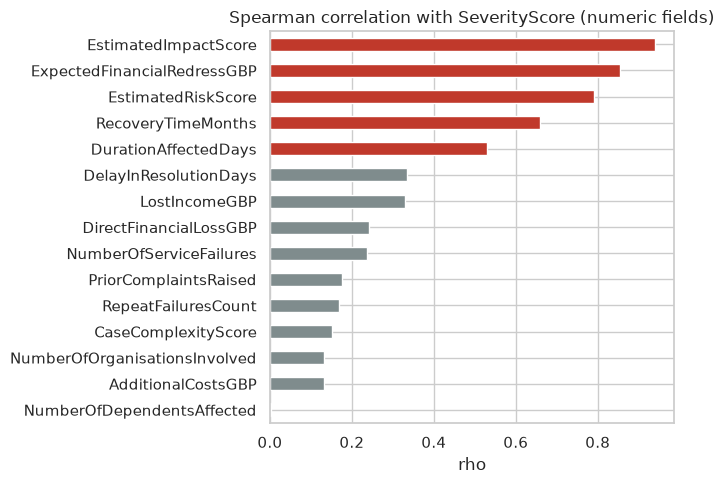

In [8]:
num = raw_train.select_dtypes("number").drop(columns=[C.TARGET])
corr = num.corrwith(raw_train[C.TARGET], method="spearman").sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
corr.plot.barh(ax=ax, color=np.where(corr.abs() > 0.5, "#c0392b", "#7f8c8d"))
ax.set(title="Spearman correlation with SeverityScore (numeric fields)", xlabel="rho")
plt.tight_layout(); fig.savefig(FIG / "spearman_numeric.png", dpi=120); plt.show()

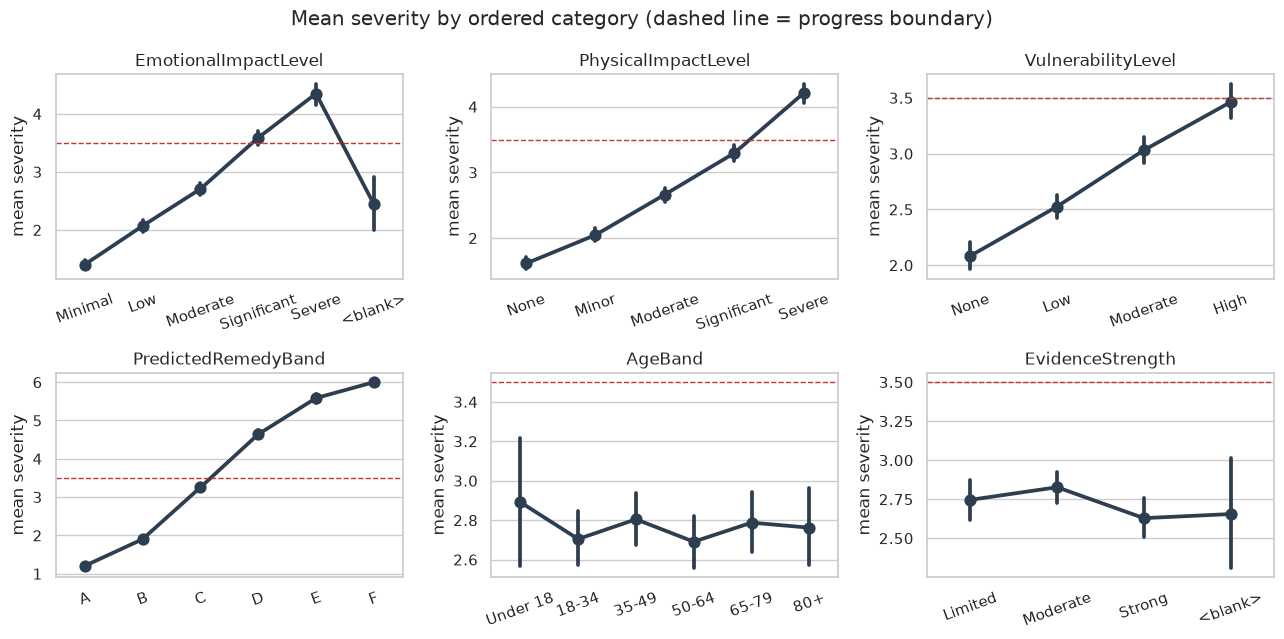

In [9]:
ordinal_cols = ["EmotionalImpactLevel", "PhysicalImpactLevel", "VulnerabilityLevel", "PredictedRemedyBand", "AgeBand", "EvidenceStrength"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, col in zip(axes.ravel(), ordinal_cols):
    order = C.ORDINAL_LEVELS[col]
    s = raw_train[col].fillna("None" if col in C.STRUCTURAL_NONE_COLUMNS else "<blank>")
    order = [o for o in order if o in s.unique()] + [x for x in s.unique() if x not in order]
    sns.pointplot(x=s, y=raw_train[C.TARGET], order=order, ax=ax, color="#2c3e50", errorbar=("ci", 95))
    ax.axhline(3.5, ls="--", c="#c0392b", lw=1); ax.set(title=col, xlabel="", ylabel="mean severity"); ax.tick_params(axis="x", rotation=20)
plt.suptitle("Mean severity by ordered category (dashed line = progress boundary)"); plt.tight_layout(); fig.savefig(FIG / "ordinal_vs_severity.png", dpi=120); plt.show()

In [10]:
flags = ["LongTermImpactFlag", "SafeguardingConcern", "BereavedPerson", "RepeatedFailurePattern", "LegalChallengePotential", "EscalatedInternally", "DeteriorationInHealth", "AdditionalTreatmentRequired"]
flag_tbl = pd.DataFrame({f: raw_train.groupby(f)[C.TARGET].mean() for f in flags}).T.rename(columns={"No": "mean_if_No", "Yes": "mean_if_Yes"})
flag_tbl["lift"] = (flag_tbl.mean_if_Yes - flag_tbl.mean_if_No).round(2)
flag_tbl["share_Yes"] = [f"{(raw_train[f]=='Yes').mean():.1%}" for f in flags]
display(flag_tbl.round(2).sort_values("lift", ascending=False))
yr = raw_train.assign(year=pd.to_datetime(raw_train.CaseCreatedDate).dt.year).groupby("year")[C.TARGET].agg(["mean", "count"]).round(2)
display(yr.T)

,mean_if_No,mean_if_Yes,lift,share_Yes
LongTermImpactFlag,2.63,4.97,2.34,5.3%
BereavedPerson,2.72,3.82,1.10,3.0%
SafeguardingConcern,2.64,3.63,0.99,11.7%
AdditionalTreatmentRequired,2.38,3.30,0.92,40.6%
RepeatedFailurePattern,2.53,3.44,0.91,25.1%
DeteriorationInHealth,2.36,3.20,0.84,46.9%
EscalatedInternally,2.73,2.85,0.12,16.4%
LegalChallengePotential,2.75,2.76,0.01,11.5%


year,2023,2024,2025,2026
mean,2.74,2.75,2.73,2.84
count,581.00,574.00,556.00,289.00


Observations that drive the feature design:

* The internal assessment scores and remedy band are by far the strongest signals, then
  `RecoveryTimeMonths` and `DurationAffectedDays`. Financial amounts matter but are heavy-tailed, so
  they are log-transformed and also summed into a total loss.
* The ordered categoricals are genuinely monotone in severity, so they are encoded as integers rather
  than one-hot, which keeps the ordering and lets a single split separate "Significant or worse".
* A handful of rare flags (`LongTermImpactFlag` 5%, `BereavedPerson` 3%, `SafeguardingConcern` 12%)
  carry a large lift. They are kept as individual features and also counted into an
  `AggravatingFactorCount`.
* `AgeBand`, `ServiceArea`, `OrganisationType`, `ComplaintCategory` and `EvidenceStrength` show
  little marginal relationship; they stay in the model for interactions but are not expected to
  dominate. Severity is flat over time, so no date features are used (they would only add drift risk).

## 2. Cleaning

`severity_triage.data.clean` applies the rules above deterministically to both training and inference
data and returns a `DataQualityReport` that is logged and, in production, would be monitored.

In [11]:
train_df, train_report = clean(raw_train, is_training=True)
hold_df, hold_report = clean(raw_hold, is_training=False)
print(json.dumps({k: v for k, v in train_report.as_dict().items() if k != "missing_after_cleaning"}, indent=1))
X, y = split_xy(train_df)

{
 "n_rows": 2000,
 "missing_columns": [],
 "unexpected_columns": [],
 "out_of_range": {
  "AdditionalCostsGBP": 2,
  "CaseComplexityScore": 2,
  "DelayInResolutionDays": 2,
  "DirectFinancialLossGBP": 2,
  "DurationAffectedDays": 2,
  "EstimatedImpactScore": 2,
  "EstimatedRiskScore": 2,
  "ExpectedFinancialRedressGBP": 2,
  "LostIncomeGBP": 2,
  "NumberOfDependentsAffected": 2,
  "NumberOfOrganisationsInvolved": 2,
  "NumberOfServiceFailures": 2,
  "PriorComplaintsRaised": 2,
  "RecoveryTimeMonths": 2,
  "RepeatFailuresCount": 2
 },
 "invalid_categories": {},
 "invalid_booleans": {},
 "structural_none_filled": {
  "PhysicalImpactLevel": 336,
  "VulnerabilityLevel": 404,
  "PrimaryVulnerability": 505,
  "FailureTypeSecondary": 925
 },
 "jurisdiction_inferred": 110,
 "duplicate_references": 0,
 "dropped_columns": [
  "OmbudsmanInvestigationRequired"
 ]
}


## 3. Feature engineering

`FeatureEngineer` (stateless, inside the saved pipeline) produces:

| Group | Features |
|---|---|
| Raw numerics (15) | validated, out-of-range → missing |
| Ordinal codes (7) | `EmotionalImpactLevel`, `PhysicalImpactLevel`, `VulnerabilityLevel`, `EvidenceStrength`, `InvestigationRoute`, `PredictedRemedyBand`, `AgeBand` |
| Booleans (13) | 0/1 |
| Nominal (7) | one-hot with unknown-safe encoding |
| Engineered (16) | `TotalFinancialLossGBP` (+log), log redress/duration/delay, `HealthImpactCount`, `MaxImpactLevel`, `VulnerabilityXImpact`, `ImpactRiskMean`/`Gap`, `RepeatFailureRatio`, `FailuresPerOrganisation`, `HasSecondaryFailure`, `SecondaryMatchesPrimary`, `LongTermOrLongRecovery`, `AggravatingFactorCount` |
| Missing indicators | one per numeric/ordinal/boolean column that has gaps |

Imputation (median) and one-hot encoding are *fitted* steps and therefore live in the sklearn pipeline,
so they are learned on training folds only during cross-validation.

(2000, 58)


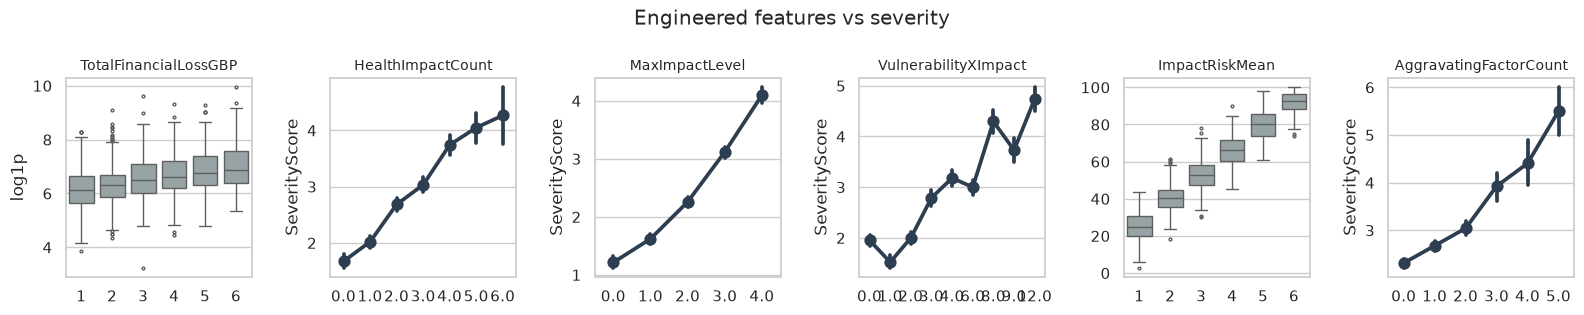

In [12]:
feats = FeatureEngineer().fit_transform(X)
print(feats.shape)
eng = ["TotalFinancialLossGBP", "HealthImpactCount", "MaxImpactLevel", "VulnerabilityXImpact", "ImpactRiskMean", "AggravatingFactorCount"]
fig, axes = plt.subplots(1, len(eng), figsize=(16, 3.2))
for ax, col in zip(axes, eng):
    if feats[col].nunique() <= 12:
        sns.pointplot(x=feats[col], y=y, ax=ax, color="#2c3e50")
    else:
        sns.boxplot(x=y, y=np.log1p(feats[col]) if "GBP" in col else feats[col], ax=ax, color="#95a5a6", fliersize=2); ax.set_ylabel("log1p" if "GBP" in col else "")
    ax.set_title(col, fontsize=10); ax.set_xlabel("")
plt.suptitle("Engineered features vs severity"); plt.tight_layout(); fig.savefig(FIG / "engineered_features.png", dpi=120); plt.show()

## 4. Modelling

**Setup.** 5-fold stratified cross-validation with a fixed seed; every metric below is computed on
out-of-fold predictions, so no case is scored by a model that saw it. Two models are compared:

* **Baseline**: multinomial logistic regression (balanced class weights) on the same features. A
  transparent reference point.
* **Main model**: LightGBM multiclass classifier with balanced class weights, shallow trees and
  subsampling for regularisation on 2,000 rows.

Both are ordinary 6-class classifiers; the ordinal structure is exploited in the *decision layer*
(section 5) rather than by a bespoke ordinal loss, which keeps the probabilities interpretable
(`P(score ≥ 4)` is just a sum) and the model easy to swap.

In [13]:
cfg = C.TrainingConfig()
baseline = build_baseline_pipeline(seed=SEED)
oof_base = cross_validate_proba(baseline, X, y, cfg.n_folds, SEED)
lgbm = build_lgbm_pipeline(cfg.lgbm_params, seed=SEED)
oof_lgbm = cross_validate_proba(lgbm, X, y, cfg.n_folds, SEED)
lgbm_no_internal = build_lgbm_pipeline(cfg.lgbm_params, exclude_internal_scores=True, seed=SEED)
oof_no_internal = cross_validate_proba(lgbm_no_internal, X, y, cfg.n_folds, SEED)

### 4.1 Model quality on the most-likely class (before any business adjustment)

In [14]:
def summarise(name, proba):
    argmax = np.asarray(C.SEVERITY_CLASSES)[proba.argmax(1)]
    s = score_metrics(y, argmax); t = triage_metrics(y, is_severe(argmax))
    from sklearn.metrics import roc_auc_score
    return {"model": name, **{k: round(v, 3) for k, v in s.items() if k in ("accuracy", "within_one_accuracy", "macro_f1", "mae", "quadratic_weighted_kappa")},
            "severe_recall": round(t["severe_recall"], 3), "severe_precision": round(t["severe_precision"], 3), "severe_AUROC": round(roc_auc_score(is_severe(y), severe_probability(proba)), 3)}
cmp = pd.DataFrame([summarise("Logistic regression", oof_base), summarise("LightGBM", oof_lgbm), summarise("LightGBM without internal scores", oof_no_internal)]).set_index("model")
display(cmp)

,accuracy,within_one_accuracy,macro_f1,mae,quadratic_weighted_kappa,severe_recall,severe_precision,severe_AUROC
model,,,,,,,,
Logistic regression,0.743,0.994,0.719,0.264,0.937,0.915,0.889,0.990
LightGBM,0.796,0.999,0.794,0.205,0.953,0.917,0.932,0.990
LightGBM without internal scores,0.458,0.860,0.448,0.699,0.758,0.687,0.717,0.906


LightGBM beats the linear baseline on every score-level metric (accuracy 0.80 vs 0.74, MAE 0.21 vs
0.26) while both rank severe cases almost equally well (AUROC 0.99). 99.9% of LightGBM predictions
are within one point of the true score, and quadratic weighted kappa of 0.95 shows the errors are
almost all between adjacent scores.

**But** with the argmax rule the main model still misses 8% of severe cases (recall 0.92). That is
the number the business cares about, and it is fixed in the decision layer rather than by changing
the model.

### 4.2 Where do the errors sit?

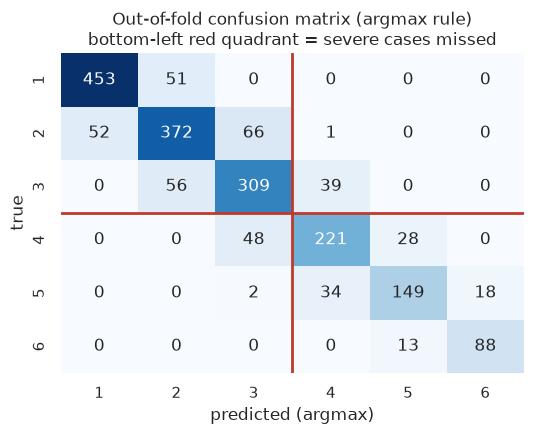

In [15]:
from sklearn.metrics import confusion_matrix
argmax = np.asarray(C.SEVERITY_CLASSES)[oof_lgbm.argmax(1)]
cm = confusion_matrix(y, argmax, labels=C.SEVERITY_CLASSES)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=C.SEVERITY_CLASSES, yticklabels=C.SEVERITY_CLASSES, ax=ax)
ax.axhline(3, c="#c0392b", lw=2); ax.axvline(3, c="#c0392b", lw=2)
ax.set(xlabel="predicted (argmax)", ylabel="true", title="Out-of-fold confusion matrix (argmax rule)\nbottom-left red quadrant = severe cases missed")
plt.tight_layout(); fig.savefig(FIG / "confusion_argmax.png", dpi=120); plt.show()

Errors are almost entirely between neighbouring scores; the costly ones are the true-4 cases predicted
as 3. Those sit right on the business boundary, which is where a tuned threshold helps most.

### 4.3 Dependence on the internal assessment fields (ablation)

In [16]:
display(cmp.loc[["LightGBM", "LightGBM without internal scores"]])

,accuracy,within_one_accuracy,macro_f1,mae,quadratic_weighted_kappa,severe_recall,severe_precision,severe_AUROC
model,,,,,,,,
LightGBM,0.796,0.999,0.794,0.205,0.953,0.917,0.932,0.990
LightGBM without internal scores,0.458,0.860,0.448,0.699,0.758,0.687,0.717,0.906


Without `EstimatedImpactScore`, `EstimatedRiskScore`, `ExpectedFinancialRedressGBP` and
`PredictedRemedyBand`, accuracy drops from 0.80 to 0.46 and severe AUROC falls from 0.99 to 0.91. The
"raw facts" of a case (durations, money, flags, impact levels) explain far less of the severity score
than the assessors' own interim scores do. Two consequences for deployment:

1. The model is only as good as those upstream assessments. If they are produced by the same people
   who later assign severity, the model is largely learning to reproduce their judgement, which is
   fine for consistency and speed but does not add independent signal.
2. If the internal scores are *not* available at the point of automatic triage, the no-internal-scores
   model must be used and the threshold re-tuned; at the same recall it would progress roughly half of
   all cases instead of a third.

## 5. Business risk and the decision rule

The decision layer converts the six class probabilities into a score and a triage decision:

1. `P(severe) = P(4) + P(5) + P(6)`.
2. **Progress** if `P(severe) ≥ τ`.
3. The reported score is the most likely class *within* the chosen band, so the score in the prediction
   file always agrees with the decision it drives.

τ is chosen on out-of-fold predictions to minimise an explicit expected cost,
`cost = FN_cost × missed severe + FP_cost × unnecessary investigations`, subject to a floor on
severe recall (default 95%). The ratio `FN_cost : FP_cost = 5 : 1` is an **assumption** encoding the
brief's "low tolerance" for missed severe cases; the chart below shows what other ratios would imply.

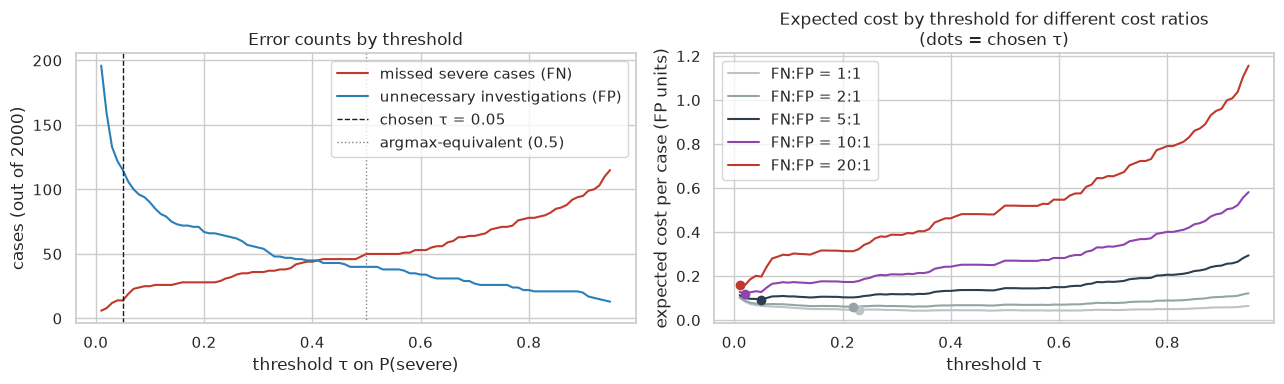

In [17]:
curve = threshold_curve(y, oof_lgbm, cfg.costs)
tau, _ = choose_threshold(y, oof_lgbm, cfg.costs, cfg.min_severe_recall)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(curve.threshold, curve.false_negative, label="missed severe cases (FN)", c="#c0392b")
ax.plot(curve.threshold, curve.false_positive, label="unnecessary investigations (FP)", c="#2980b9")
ax.axvline(tau, ls="--", c="k", lw=1, label=f"chosen τ = {tau:.2f}"); ax.axvline(0.5, ls=":", c="grey", lw=1, label="argmax-equivalent (0.5)")
ax.set(xlabel="threshold τ on P(severe)", ylabel="cases (out of 2000)", title="Error counts by threshold"); ax.legend()
ax = axes[1]
for ratio, c in [(1, "#bdc3c7"), (2, "#95a5a6"), (5, "#2c3e50"), (10, "#8e44ad"), (20, "#c0392b")]:
    cc = threshold_curve(y, oof_lgbm, C.BusinessCosts(ratio, 1))
    ax.plot(cc.threshold, cc.expected_cost_per_case, label=f"FN:FP = {ratio}:1", c=c)
    t_best, _ = choose_threshold(y, oof_lgbm, C.BusinessCosts(ratio, 1), cfg.min_severe_recall)
    ax.scatter([t_best], [cc.loc[cc.threshold == t_best, "expected_cost_per_case"].iloc[0]], c=c, zorder=5)
ax.set(xlabel="threshold τ", ylabel="expected cost per case (FP units)", title="Expected cost by threshold for different cost ratios\n(dots = chosen τ)"); ax.legend()
plt.tight_layout(); fig.savefig(FIG / "threshold_tradeoff.png", dpi=120); plt.show()

In [18]:
show = curve[curve.threshold.isin([0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7])].copy()
show["severe_recall"] = show.severe_recall.round(3); show["severe_precision"] = show.severe_precision.round(3); show["progress_rate"] = show.progress_rate.round(3)
display(show[["threshold", "false_negative", "false_positive", "severe_recall", "severe_precision", "progress_rate", "expected_cost_per_case"]].set_index("threshold"))
sens = pd.DataFrame([{"FN:FP": f"{r}:1", "chosen_tau": choose_threshold(y, oof_lgbm, C.BusinessCosts(r, 1), cfg.min_severe_recall)[0]} for r in (1, 2, 3, 5, 10, 20)])
sens = sens.merge(curve.rename(columns={"threshold": "chosen_tau"})[["chosen_tau", "false_negative", "false_positive", "severe_recall", "progress_rate"]], on="chosen_tau")
display(sens.round(3).set_index("FN:FP"))

,false_negative,false_positive,severe_recall,severe_precision,progress_rate,expected_cost_per_case
threshold,,,,,,
0.02,8,159,0.987,0.789,0.376,0.0995
0.05,14,115,0.977,0.836,0.351,0.0925
0.10,25,90,0.958,0.865,0.333,0.1075
0.20,28,67,0.953,0.895,0.320,0.1035
0.30,36,55,0.940,0.911,0.310,0.1175
0.50,50,40,0.917,0.932,0.296,0.1450
0.70,64,27,0.894,0.952,0.282,0.1735


,chosen_tau,false_negative,false_positive,severe_recall,progress_rate
FN:FP,,,,,
1:1,0.23,29,65,0.952,0.318
2:1,0.22,28,66,0.953,0.320
3:1,0.22,28,66,0.953,0.320
5:1,0.05,14,115,0.977,0.351
10:1,0.02,8,159,0.987,0.376
20:1,0.01,6,196,0.990,0.396


**Reading the trade-off.** Moving from the naive argmax rule (τ ≈ 0.5) to the chosen τ cuts missed
severe cases from 50 to 14 per 2,000 (recall 0.92 → 0.98) at the price of about 75 extra
investigations, i.e. the progress rate rises from 30% to 35%. Below τ ≈ 0.05 there is little left to
gain: the remaining misses are cases the model is confident are low severity, and each further
percentage point of recall costs a fast-growing number of investigations.

The sensitivity table shows what the cost ratio actually decides. Because of the 95% recall floor,
even a 1:1 ratio selects τ ≈ 0.22 (recall 95%, 28 misses, 32% progressed), never the argmax rule.
Ratios of 5:1 or steeper move τ to 0.05 or below, trading roughly 50-130 extra investigations for
6-22 fewer missed severe cases. The real choice is therefore between τ ≈ 0.2 and τ ≈ 0.05; this
notebook makes that trade-off explicit so the business can own it, and it is a one-line config change.

### 5.1 Final cross-validated performance with the chosen rule

,score-level,argmax reference
accuracy,0.779,0.796
within_one_accuracy,0.996,0.998
macro_f1,0.778,0.794
mae,0.224,0.206
quadratic_weighted_kappa,0.948,0.953
under_prediction_rate,0.084,0.102
over_prediction_rate,0.136,0.102


,triage,argmax reference
true_positive,587.000,551.000
false_negative,14.000,50.000
false_positive,115.000,40.000
true_negative,1284.000,1359.000
severe_recall,0.977,0.917
severe_precision,0.836,0.932
specificity,0.918,0.971
progress_rate,0.351,0.296
missed_severe_rate,0.007,0.025
expected_cost_per_case,0.092,0.145


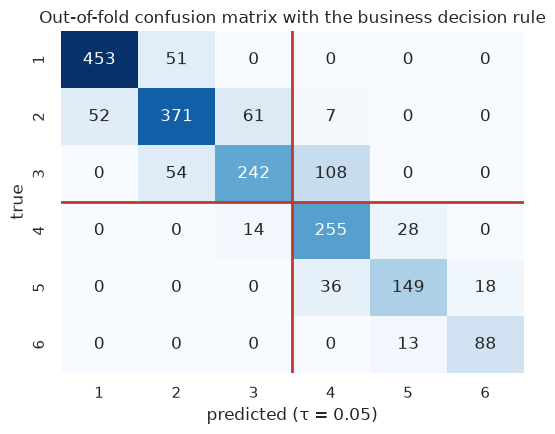

In [19]:
final_cv = full_evaluation(y, oof_lgbm, tau, cfg.costs)
display(pd.DataFrame({"score-level": final_cv["score"], "argmax reference": final_cv["argmax_reference"]["score"]}).round(3))
display(pd.DataFrame({"triage": final_cv["triage"], "argmax reference": final_cv["argmax_reference"]["triage"]}).round(3))
score_dec, progress_dec, _ = decode_scores(oof_lgbm, tau)
cm2 = confusion_matrix(y, score_dec, labels=C.SEVERITY_CLASSES)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=C.SEVERITY_CLASSES, yticklabels=C.SEVERITY_CLASSES, ax=ax)
ax.axhline(3, c="#c0392b", lw=2); ax.axvline(3, c="#c0392b", lw=2)
ax.set(xlabel=f"predicted (τ = {tau:.2f})", ylabel="true", title="Out-of-fold confusion matrix with the business decision rule")
plt.tight_layout(); fig.savefig(FIG / "confusion_business_rule.png", dpi=120); plt.show()

The cost of the safer rule is visible in the score-level metrics: accuracy drops two points (0.80 →
0.78) because borderline 3s are now called 4s. That is the intended behaviour: under-prediction falls
from 10% to 8% while over-prediction rises, and the errors that remain are almost all one point off.

### 5.2 Which severe cases are still missed?

In [20]:
missed = train_df.loc[is_severe(y) & ~progress_dec, ["CaseReference", C.TARGET, "EstimatedImpactScore", "EstimatedRiskScore", "PredictedRemedyBand", "ExpectedFinancialRedressGBP", "EmotionalImpactLevel", "PhysicalImpactLevel", "RecoveryTimeMonths", "LongTermImpactFlag"]].copy()
missed["P_severe"] = severe_probability(oof_lgbm)[missed.index].round(3)
display(missed.sort_values("P_severe", ascending=False))
print("median EstimatedImpactScore: all severe =", train_df.loc[is_severe(y), "EstimatedImpactScore"].median(), "| missed severe =", missed.EstimatedImpactScore.median())

,CaseReference,SeverityScore,EstimatedImpactScore,EstimatedRiskScore,PredictedRemedyBand,ExpectedFinancialRedressGBP,EmotionalImpactLevel,PhysicalImpactLevel,RecoveryTimeMonths,LongTermImpactFlag,P_severe
908,TRN-000909,4,56.0,55.0,C,1158.84,Significant,None,2.0,False,0.033
904,TRN-000905,4,56.0,35.0,D,6975.22,Significant,Severe,4.0,False,0.032
1338,TRN-001339,4,66.0,45.0,C,797.27,Moderate,Significant,5.0,False,0.028
61,TRN-000062,4,67.0,45.0,C,949.53,Moderate,None,4.0,False,0.027
944,TRN-000945,4,56.0,60.0,D,3578.39,Severe,None,1.0,False,0.024
1280,TRN-001281,4,55.0,73.0,C,1298.60,Moderate,Moderate,12.0,False,0.024
550,TRN-000551,4,62.0,60.0,C,1272.09,Significant,Severe,1.0,False,0.020
616,TRN-000617,4,53.0,68.0,C,1238.26,Low,Minor,2.0,False,0.014
688,TRN-000689,4,63.0,53.0,C,1475.96,Severe,Significant,2.0,False,0.010
1939,TRN-001940,4,54.0,67.0,B,717.16,Significant,Moderate,3.0,False,0.007


median EstimatedImpactScore: all severe = 80.0 | missed severe = 56.0


All 14 remaining misses are true 4s whose internal assessments (impact score, remedy band, redress)
look like a typical score-3 case: their median impact score is 56 against 80 for severe cases as a
whole. The model has no information that contradicts the upstream assessment, so these are cases where
the assessor's interim scores and their final severity disagree. They are not spread evenly: cases with
`P(severe)` between 0.02 and τ are only 50 of 2,000 (2.5%) yet contain 6 of the 14 misses. In
production that narrow band is the natural place for a light-touch human check rather than automatic
closure.

## 6. Explainability

The final model is fitted on all training data. SHAP values from the tree model give both a global
view (which features drive severity) and a per-case view (why *this* case was progressed), which is
what a caseworker or auditor needs when the automatic triage is questioned.

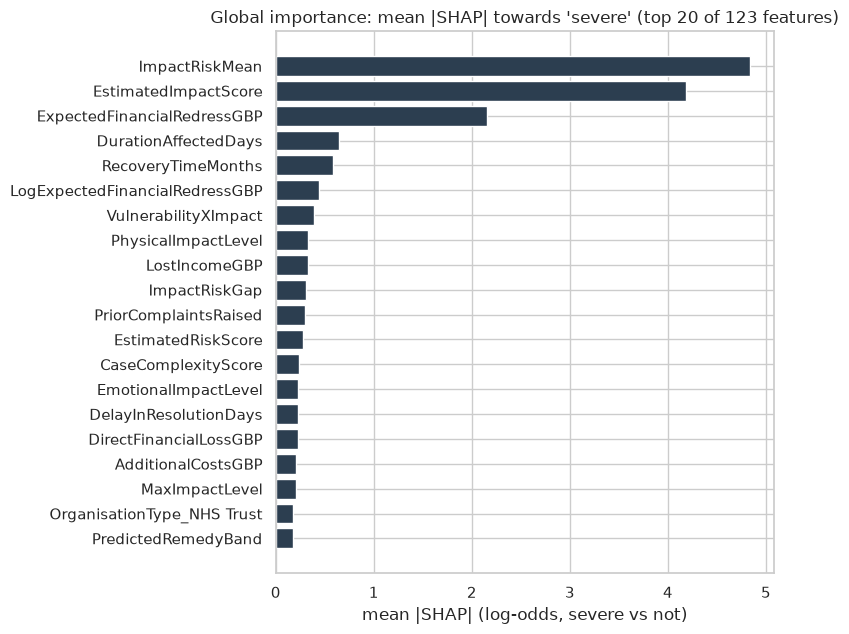

In [21]:
lgbm.fit(X, y)
model = SeverityModel(pipeline=lgbm, threshold=tau)
sv, Xt = shap_values(model, X)
imp = global_importance(sv, model.feature_names)
fig, ax = plt.subplots(figsize=(8, 6.5))
top = imp.sort_values('mean_abs_severe_shap', ascending=False).head(20).iloc[::-1]
ax.barh(top.feature, top.mean_abs_severe_shap, color="#2c3e50")
ax.set(title="Global importance: mean |SHAP| towards 'severe' (top 20 of %d features)" % len(imp), xlabel="mean |SHAP| (log-odds, severe vs not)")
plt.tight_layout(); fig.savefig(FIG / "shap_global.png", dpi=120); plt.show()

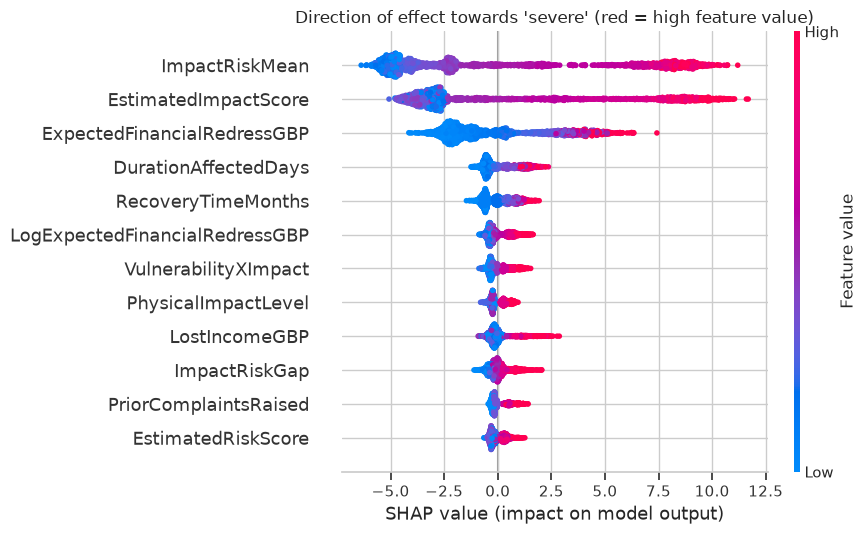

In [22]:
import shap
sev = severe_contributions(sv)
top_feats = imp.sort_values('mean_abs_severe_shap', ascending=False).head(12).feature.tolist()
idx = [model.feature_names.index(f) for f in top_feats]
fig = plt.figure(figsize=(9, 5.5))
shap.summary_plot(sev[:, idx], Xt.iloc[:, idx], feature_names=top_feats, show=False, plot_size=None)
plt.title("Direction of effect towards 'severe' (red = high feature value)"); plt.tight_layout(); fig.savefig(FIG / "shap_beeswarm.png", dpi=120, bbox_inches="tight"); plt.show()

The model's reasoning matches the brief's own list of severity factors. The internal impact / risk
scores and their mean dominate; then expected financial redress, duration of impact and recovery time,
the vulnerability × impact interaction, lost income and the physical and emotional impact levels. All
act in the expected direction: higher values push towards severe. Demographic and organisational
fields (`AgeBand`, `ServiceArea`, `OrganisationType`) carry little weight, which is reassuring from a
fairness standpoint: the decision is driven by what happened to the person, not by who they are or
which body they complained about.

### 6.1 Explaining an individual decision

Case TRN-001588: true score 4, OOF P(severe) = 0.052, decision = Progress


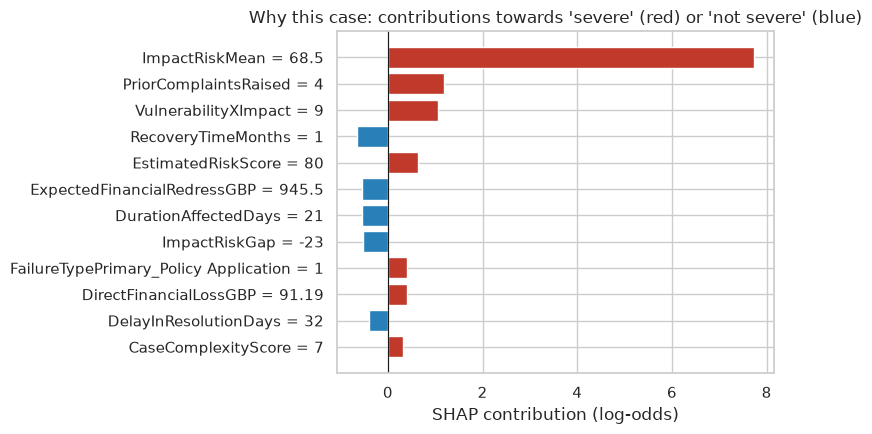

ImpactRiskMean=68.50 (+7.74); PriorComplaintsRaised=4 (+1.18); VulnerabilityXImpact=9 (+1.06)


In [23]:
p_sev_oof = severe_probability(oof_lgbm)
border = int(np.argmin(np.abs(p_sev_oof - tau) + (y.values != 4) * 10))  # a true-4 case near the threshold
case = X.iloc[[border]]
print(f"Case {case.CaseReference.iloc[0]}: true score {y.iloc[border]}, OOF P(severe) = {p_sev_oof[border]:.3f}, decision = {'Progress' if p_sev_oof[border] >= tau else 'Do not progress'}")
contrib = pd.Series(sev[border], index=model.feature_names)
top_c = contrib.reindex(contrib.abs().sort_values(ascending=False).index[:12])
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [f"{f} = {Xt.iloc[border][f]:.4g}" for f in top_c.index]
ax.barh(labels[::-1], top_c.values[::-1], color=["#c0392b" if v > 0 else "#2980b9" for v in top_c.values[::-1]])
ax.axvline(0, c="k", lw=0.8); ax.set(title="Why this case: contributions towards 'severe' (red) or 'not severe' (blue)", xlabel="SHAP contribution (log-odds)")
plt.tight_layout(); fig.savefig(FIG / "shap_local_example.png", dpi=120); plt.show()
print(top_drivers(model, case).iloc[0])

The same `top_drivers` helper writes a `TopDrivers` column into the prediction file, giving each
decision a short, auditable reason string.

## 7. Holdback predictions

### 7.1 Is the holdback data like the training data?
Before scoring, we check for drift: a model can only be trusted on data that resembles what it saw.

In [24]:
from scipy.stats import ks_2samp, chi2_contingency
drift = []
for col in C.NUMERIC_COLUMNS:
    a, b = train_df[col].dropna(), hold_df[col].dropna()
    drift.append({"column": col, "type": "numeric", "train_median": a.median(), "holdback_median": b.median(), "KS_p": ks_2samp(a, b).pvalue})
for col in list(C.ORDINAL_LEVELS) + C.NOMINAL_COLUMNS + C.BOOLEAN_COLUMNS:
    ct = pd.crosstab(pd.concat([train_df[col].astype(object), hold_df[col].astype(object)]).fillna("<na>"), np.r_[np.zeros(len(train_df)), np.ones(len(hold_df))])
    drift.append({"column": col, "type": "categorical", "train_median": None, "holdback_median": None, "KS_p": chi2_contingency(ct)[1]})
drift = pd.DataFrame(drift).rename(columns={"KS_p": "p_value"})
print("columns with p < 0.01 (evidence of a distribution shift):", drift.loc[drift.p_value < 0.01, "column"].tolist() or "none")
display(drift.sort_values("p_value").head(8).round(3))

columns with p < 0.01 (evidence of a distribution shift): none


,column,type,train_median,holdback_median,p_value
34,EscalatedInternally,categorical,NaN,NaN,0.013
20,InvestigationRoute,categorical,NaN,NaN,0.039
16,EmotionalImpactLevel,categorical,NaN,NaN,0.039
17,PhysicalImpactLevel,categorical,NaN,NaN,0.047
15,AgeBand,categorical,NaN,NaN,0.106
23,FailureTypePrimary,categorical,NaN,NaN,0.125
22,ComplaintCategory,categorical,NaN,NaN,0.139
33,DeteriorationInHealth,categorical,NaN,NaN,0.157


No feature shows a meaningful shift between training and holdback data, so the cross-validated
estimates above are a fair expectation for the holdback predictions.

### 7.2 Score the holdback cases
The prediction file is produced by the same code path as the CLI (`severity-predict`), from the raw
holdback file, so this cell and the command line give identical output.

In [25]:
from severity_triage.predict import predict_dataframe
preds, hold_quality = predict_dataframe(model, raw_hold, explain=True)
out = C.PREDICTIONS_DIR / "holdback_predictions.csv"
display(preds.head())
print("predicted score distribution:", preds.PredictedSeverityScore.value_counts(normalize=True).sort_index().round(3).to_dict())
print(f"progressed: {(preds.TriageDecision == 'Progress').mean():.1%}  (training base rate of true severe cases: {is_severe(y).mean():.1%})")
saved = pd.read_csv(out)
print("matches the file written by `severity-predict`:", saved[["CaseReference", "PredictedSeverityScore", "TriageDecision"]].equals(preds[["CaseReference", "PredictedSeverityScore", "TriageDecision"]]))

,CaseReference,PredictedSeverityScore,TriageDecision,ProbabilitySevere,P_Severity1,P_Severity2,P_Severity3,P_Severity4,P_Severity5,P_Severity6,TopDrivers
0,HLD-000001,5,Progress,0.9510,0.0004,0.0105,0.0382,0.1050,0.7325,0.1134,ImpactRiskMean=93 (+10.72); ExpectedFinancialR...
1,HLD-000002,4,Progress,0.9997,0.0000,0.0000,0.0002,0.9235,0.0762,0.0001,ImpactRiskMean=77.50 (+9.36); EstimatedImpactS...
2,HLD-000003,1,Do not progress,0.0000,0.9993,0.0007,0.0000,0.0000,0.0000,0.0000,ImpactRiskMean=26.50 (-5.54); EstimatedImpactS...
3,HLD-000004,3,Do not progress,0.0175,0.0001,0.0012,0.9812,0.0171,0.0003,0.0000,ImpactRiskMean=62.50 (+5.37); EstimatedImpactS...
4,HLD-000005,4,Progress,0.9959,0.0000,0.0000,0.0040,0.9911,0.0049,0.0000,ImpactRiskMean=76 (+9.12); EstimatedImpactScor...


predicted score distribution: {1: 0.27, 2: 0.21, 3: 0.17, 4: 0.202, 5: 0.09, 6: 0.058}
progressed: 35.0%  (training base rate of true severe cases: 30.0%)
matches the file written by `severity-predict`: True


The predicted score distribution mirrors the training distribution, with a progress rate of 35%
against a 30% base rate: the model is deliberately erring on the side of investigation, as designed.

## 8. Conclusions

**What was built.** A LightGBM severity classifier wrapped in a cost-aware decision layer, with
deterministic cleaning driven by the data dictionary, engineered features that follow the brief's own
list of severity factors, SHAP explanations per case, and a CLI / package so training and scoring are
repeatable (`make train`, `make predict`, `make test`).

**Performance (5-fold out-of-fold, 2,000 cases).**

| | argmax rule | business rule (τ = 0.05) |
|---|---|---|
| severe-case recall | 0.92 | **0.98** |
| missed severe cases | 50 | **14** |
| unnecessary investigations | 40 | 115 |
| progress rate | 30% | 35% |
| exact-score accuracy | 0.80 | 0.78 |
| within-one-point accuracy | 0.998 | 0.996 |

**Key assumptions to confirm with the business.**

1. The four internal assessment fields are available when a case is triaged automatically. The model
   depends on them heavily (section 4.3).
2. A missed severe case is about five times as costly as an unnecessary investigation. The threshold
   is a one-line config change if the ratio is different, and section 5 shows the consequences.
3. Blank `PhysicalImpactLevel` / `VulnerabilityLevel` / `PrimaryVulnerability` / `FailureTypeSecondary`
   mean "None"; out-of-dictionary numeric values are errors.

**Recommended operating model.** Automatic closure only when `P(severe)` is well below τ; a
human-review band for cases near the threshold (section 5.2); automatic progression above it. Monitor
the data-quality report, the progress rate and, once outcomes are known, the realised recall on
severe cases, and re-tune τ or retrain when they move.

**Next steps.** Probability calibration and a formal ordinal objective; conformal prediction to give
each case a coverage-guaranteed score range; a fairness audit across `AgeBand` and `PrimaryVulnerability`
on realised outcomes; hyper-parameter search once more data is available (2,000 rows limits what can
be learned reliably).